# Autonomous Systems Portfolio 1  

|Name     |Studentnumber|Github    |
|---------|-------------|----------|
|Henry Lau|22122958     |HenryLau08|
|Michal|||
|Mohamed|22143572|mobelaachir|

Game: Connect 4

In [3]:
pip install pettingzoo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Strategie Geef Niet Op

De “Strategie Geef Niet Op” is een slimme, verdedigende manier om Vier op een Rij te spelen.
Je speelt rustig en geeft niet op, ook niet als het moeilijk wordt. In plaats van snel aan te vallen, bouw je eerst een sterke en veilige verdediging. Je neemt weinig risico en zorgt dat je tegenstander steeds minder keuzes heeft.
Met kleine, slimme zetten dwing je de tegenstander tot fouten. Daarna kies je het juiste moment om toe te slaan en te winnen.



1. Win of blokkeer meteen:

        - Kun je direct winnen? Doe dat meteen.
        - Kan je tegenstander winnen? Blokkeer dat direct. 
2. Maak geen zwakke plekken:

        - Doe geen zet die je tegenstander laat winnen in de volgende beurt.
        - Denk dus altijd één stap vooruit.
3. Bouw een sterke basis:

        - Speel vooral onderaan en in het midden van het bord.
4. Wees geduldig:

        - Val niet zomaar aan. Wacht op fouten van je tegenstander.
5. Beperk de keuzes van de tegenstander: 

        - Minder opties geven aan de tegenstander.
        - Zorg dat je de controle over het spel hebt.


Met de “Strategie Geef Niet Op” speel je rustig, slim en geduldig.
Je maakt weinig fouten en wacht op het juiste moment om te winnen.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pettingzoo.classic import connect_four_v3
from IPython.display import clear_output, display

%matplotlib inline

# -----------------------------
# 1. Initialisatie
# -----------------------------
env = connect_four_v3.env(render_mode="rgb_array")
env.reset(seed=42)

# -----------------------------
# 2. Helpers & Conversie
# -----------------------------
def convert_observation(obs):
    board = np.zeros((6, 7), dtype=int)
    for i in range(6):
        for j in range(7):
            if obs[i, j, 0] == 1: board[i, j] = 1
            elif obs[i, j, 1] == 1: board[i, j] = 2
    return board

def print_text_board(board, mask):
    print("\nCurrent board:")
    for i in range(6):
        row = []
        for j in range(7):
            if board[i, j] == 1: row.append("X")
            elif board[i, j] == 2: row.append("O")
            else: row.append(".")
        print(" ".join(row))
    print("\nColumns: " + " ".join([str(i) if mask[i] else "x" for i in range(7)]))

def drop_piece(board, col, player):
    new_board = board.copy()
    for row in range(5, -1, -1):
        if new_board[row, col] == 0:
            new_board[row, col] = player
            return new_board
    return None

def check_win(board, player):
    rows, cols = board.shape
    # Horizontaal, Verticaal, Diagonaal checks
    for r in range(rows):
        for c in range(cols - 3):
            if all(board[r, c + i] == player for i in range(4)): return True
    for r in range(rows - 3):
        for c in range(cols):
            if all(board[r + i, c] == player for i in range(4)): return True
    for r in range(rows - 3):
        for c in range(cols - 3):
            if all(board[r + i, c + i] == player for i in range(4)): return True
    for r in range(3, rows):
        for c in range(cols - 3):
            if all(board[r - i, c + i] == player for i in range(4)): return True
    return False


In [8]:
# -----------------------------
# 3.STRATEGIE
# -----------------------------
def strategy_player_2(observation, agent):
    board = observation["board"]
    mask = observation["action_mask"]
    player = 2 # Computer (O)
    opponent = 1 # Jij (X)
    valid_moves = np.where(mask)[0]
    
    # 1. Blokkeer/Win direct
    for p in [player, opponent]:
        for col in valid_moves:
            temp = drop_piece(board, col, p)
            if temp is not None and check_win(temp, p): return int(col)

    # 2. Veilige zetten (geen zwakke plekken)
    safe_moves = []
    for col in valid_moves:
        temp_board = drop_piece(board, col, player)
        next_mask = [1 if temp_board[0, c] == 0 else 0 for c in range(7)]
        can_opp_win = any(check_win(drop_piece(temp_board, c, opponent), opponent) 
                          for c in range(7) if next_mask[c] and drop_piece(temp_board, c, opponent) is not None)
        if not can_opp_win: safe_moves.append(col)
    
    # 3-6. Midden, Basis, Geduld
    use_cols = safe_moves if safe_moves else valid_moves
    center_priority = [3, 2, 4, 1, 5, 0, 6]
    for col in center_priority:
        if col in use_cols: return int(col)
    return int(np.random.choice(valid_moves))

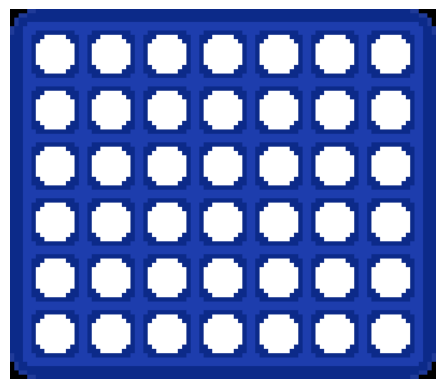


Current board:
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .

Columns: 0 1 2 3 4 5 6
Voer een getal in.


In [ ]:
# -----------------------------
# 4. Game Loop
# -----------------------------
for agent in env.agent_iter():
    raw_observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        clear_output(wait=True)
        display(plt.imshow(env.render()))
        plt.axis('off')
        plt.show()
        if reward == 1:
            print("\nGEFELICITEERD! Je hebt gewonnen!" if agent == "player_0" else "\nComputer wint!")
        elif reward == 0:
            print("\nGelijkspel!")
        break

    board = convert_observation(raw_observation["observation"])
    observation = {"board": board, "action_mask": raw_observation["action_mask"]}

    # UI Update
    clear_output(wait=True)
    rgb_image = env.render()
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()
    print_text_board(board, observation["action_mask"])

    if agent == "player_0":
        while True:
            try:
                action = int(input("Jouw beurt (0-6): "))
                if 0 <= action < 7 and observation["action_mask"][action]: break
                print("Ongeldige zet.")
            except: print("Voer een getal in.")
    else:
        print("\nComputer denkt na met jouw strategie...")
        action = strategy_player_2(observation, agent)

    env.step(action)

env.close()


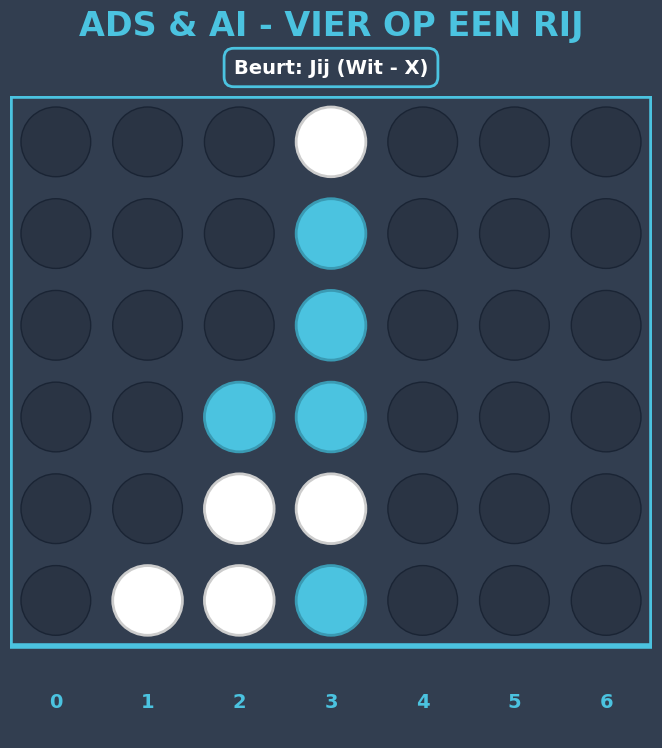


Current board:
. . . X . . .
. . . O . . .
. . . O . . .
. . O O . . .
. . X X . . .
. X X O . . .

Columns: 0 1 2 x 4 5 6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output, display
import time

# Zorgt voor directe weergave in notebooks
%matplotlib inline

# ==================== ADS & AI DESIGN CONFIGURATIE ====================
BOARD_COLOR = '#323E50'    # Het donkerblauw/grijs van de achtergrond
TEXT_COLOR = '#FFFFFF'     # Wit voor tekst
ACCENT_COLOR = '#4BC3E0'   # Het lichtblauwe van het kader
PLAYER_COLOR = '#FFFFFF'   # Wit voor de speler (Jij)
AI_COLOR = '#4BC3E0'       # Lichtblauw voor de AI (ADS & AI)
EMPTY_COLOR = '#2A3444'    # Donkerder blauw voor lege plekken

BOARD_WIDTH = 7
BOARD_HEIGHT = 6

# ==================== HELPERS ====================
def convert_observation(obs):
    board = np.zeros((6, 7), dtype=int)
    for i in range(6):
        for j in range(7):
            if obs[i, j, 0] == 1: board[i, j] = 1
            elif obs[i, j, 1] == 1: board[i, j] = 2
    return board

def print_text_board(board, mask):
    """De tekstuele weergave onder het bord"""
    print("\nCurrent board:")
    for i in range(6):
        row = []
        for j in range(7):
            if board[i, j] == 1: row.append("X")
            elif board[i, j] == 2: row.append("O")
            else: row.append(".")
        print(" ".join(row))
    print("\nColumns: " + " ".join([str(i) if mask[i] else "x" for i in range(7)]))

def drop_piece(board, col, player):
    new_board = board.copy()
    for row in range(5, -1, -1):
        if new_board[row, col] == 0:
            new_board[row, col] = player
            return new_board
    return None

def check_win(board, player):
    rows, cols = board.shape
    for r in range(rows):
        for c in range(cols - 3):
            if all(board[r, c + i] == player for i in range(4)): return True
    for r in range(rows - 3):
        for c in range(cols):
            if all(board[r + i, c] == player for i in range(4)): return True
    for r in range(rows - 3):
        for c in range(cols - 3):
            if all(board[r + i, c + i] == player for i in range(4)): return True
    for r in range(3, rows):
        for c in range(cols - 3):
            if all(board[r - i, c + i] == player for i in range(4)): return True
    return False

# ==================== GAME DESIGN RENDERING ====================
def draw_game_board(ax, board):
    """Teken het bord met ADS & AI design en kolomnummers"""
    ax.set_xlim(-0.5, BOARD_WIDTH - 0.5)
    ax.set_ylim(-0.5, BOARD_HEIGHT + 0.5) # Ruimte voor nummers aan de onderkant
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    
    # Teken het bord achtergrond
    board_rect = patches.Rectangle((-0.5, -0.5), BOARD_WIDTH, BOARD_HEIGHT, 
                                    linewidth=4, edgecolor=ACCENT_COLOR, facecolor=BOARD_COLOR)
    ax.add_patch(board_rect)
    
    # Teken cellen en schijven
    for row in range(BOARD_HEIGHT):
        for col in range(BOARD_WIDTH):
            # Schijven
            if board[row, col] == 1:  # Speler (Wit)
                circle = patches.Circle((col, row), 0.38, color=PLAYER_COLOR, ec='#CCCCCC', linewidth=2)
                ax.add_patch(circle)
            elif board[row, col] == 2:  # AI (Lichtblauw)
                circle = patches.Circle((col, row), 0.38, color=AI_COLOR, ec='#3A9AB3', linewidth=2)
                ax.add_patch(circle)
            else:  # Leeg
                circle = patches.Circle((col, row), 0.38, color=EMPTY_COLOR, ec='#1A2434', linewidth=1)
                ax.add_patch(circle)
                
    # VOEG KOLOMNUMMERS TOE AAN DE ONDERKANT
    for col in range(BOARD_WIDTH):
        ax.text(col, BOARD_HEIGHT, str(col), ha='center', va='top', 
                fontsize=14, fontweight='bold', color=ACCENT_COLOR)

def create_game_ui(board, current_player, game_status=""):
    """Creëer de volledige ADS & AI UI"""
    fig = plt.figure(figsize=(10, 8), facecolor=BOARD_COLOR)
    
    # Hoofd bord
    ax_board = plt.subplot(111)
    draw_game_board(ax_board, board)
    
    # Titel met ADS & AI kleuren
    title_text = "ADS & AI - VIER OP EEN RIJ"
    fig.suptitle(title_text, fontsize=24, fontweight='bold', color=ACCENT_COLOR, y=0.98)
    
    # Status bar
    player_info = f"Beurt: {'Jij (Wit - X)' if current_player == 1 else 'Computer (Blauw - O)'}"
    fig.text(0.5, 0.90, player_info, ha='center', fontsize=14, 
             color=TEXT_COLOR, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=BOARD_COLOR, edgecolor=ACCENT_COLOR, linewidth=2))
    
    if game_status:
        fig.text(0.5, 0.05, game_status, ha='center', fontsize=14, 
                 color=ACCENT_COLOR, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor=BOARD_COLOR, edgecolor=TEXT_COLOR, linewidth=2))
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    return fig

# ==================== STRATEGIE ====================
def strategy_player_2(board, mask):
    player = 2
    opponent = 1
    valid_moves = np.where(mask)[0]
    
    # 1. Direct winnen of blokkeren
    for p in [player, opponent]:
        for col in valid_moves:
            temp = drop_piece(board, col, p)
            if temp is not None and check_win(temp, p): return int(col)

    # 2. Veilige zetten (Jouw strategie)
    safe_moves = []
    for col in valid_moves:
        temp_board = drop_piece(board, col, player)
        next_mask = [1 if temp_board[0, c] == 0 else 0 for c in range(7)]
        can_opp_win = any(check_win(drop_piece(temp_board, c, opponent), opponent) 
                          for c in range(7) if next_mask[c] and drop_piece(temp_board, c, opponent) is not None)
        if not can_opp_win: safe_moves.append(col)
    
    use_cols = safe_moves if safe_moves else valid_moves
    center_priority = [3, 2, 4, 1, 5, 0, 6]
    for col in center_priority:
        if col in use_cols: return int(col)
    return int(np.random.choice(valid_moves))
    

# ==================== GAME LOOP ====================
from pettingzoo.classic import connect_four_v3

env = connect_four_v3.env(render_mode="rgb_array")
env.reset(seed=42)

for agent in env.agent_iter():
    raw_observation, reward, termination, truncation, info = env.last()
    board = convert_observation(raw_observation["observation"])
    mask = raw_observation["action_mask"]
    
    # UI Update
    clear_output(wait=True)
    current_player = 1 if agent == "player_0" else 2
    
    if termination or truncation:
        if reward == 1:
            status = "GEWONNEN!" if agent == "player_0" else "ADS & AI WINT!"
        elif reward == -1:
            status = "ADS & AI WINT!" if agent == "player_0" else "GEWONNEN!"
        else:
            status = "GELIJKSPEL!"
            
        fig = create_game_ui(board, current_player, status)
        plt.show()
        print_text_board(board, mask)
        break
    
    fig = create_game_ui(board, current_player)
    plt.show()
    print_text_board(board, mask)
    
    if agent == "player_0":
        while True:
            try:
                action = int(input("\nVoer een getal in (0-6): "))
                if 0 <= action < 7 and mask[action]: break
                print("Ongeldige zet.")
            except: print("Voer a.u.b. een getal in.")
    else:
        print("\nADS & AI denkt na...")
        time.sleep(1)
        action = strategy_player_2(board, mask)
    
    env.step(action)

env.close()
